# Data Wrangling — Dataset Klasifikasi Sampah

## BUSINESS QUESTIONS
1. Apakah distribusi jumlah gambar antar kelas sudah seimbang (tidak terjadi class imbalance)?
2. Berapa persentase gambar yang tidak valid (rusak, resolusi terlalu kecil, atau mode warna bukan RGB)?
3. Apakah terdapat duplikasi nama file yang berpotensi menyebabkan data leakage antar kelas?
4. Format file apa yang paling dominan digunakan dalam dataset, dan apakah perlu standarisasi format sebelum pelatihan model?

## IMPORT LIBRARY

In [1]:
pip install Pillow pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import shutil
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## KONFIGURASI GLOBAL

In [3]:
DATASET_DIR = Path("dataset")

CLASSES = [
    "hazardous",
    "Kaca",
    "Kardus",
    "Kertas",
    "Logam",
    "organic",
    "Plastik",
    "recyclable",
    "Residu"
]

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp"]

## DATA GATHERING

In [4]:
LABEL_MAPPING = {
    "battery": "hazardous",
    "batteries": "hazardous",
    "e-waste": "hazardous",
    "hazardous": "hazardous",

    "glass": "Kaca",
    "kaca": "Kaca",

    "cardboard": "Kardus",
    "kardus": "Kardus",

    "paper": "Kertas",
    "kertas": "Kertas",

    "metal": "Logam",
    "logam": "Logam",

    "food-waste": "organic",
    "food waste": "organic",
    "organic": "organic",
    "organik": "organic",
    "garden-waste": "organic",
    "other-organic-waste": "organic",

    "plastic": "Plastik",
    "plastik": "Plastik",

    "recyclable": "recyclable",
    "recycle": "recyclable",

    "trash": "Residu",
    "residu": "Residu",
    "residual": "Residu",
    "general trash": "Residu"
}

In [5]:
def create_folder_structure():
    """Membuat folder kelas akhir di dalam folder dataset."""
    DATASET_DIR.mkdir(exist_ok=True)

    for cls in CLASSES:
        (DATASET_DIR / cls).mkdir(parents=True, exist_ok=True)

    print("Struktur folder dataset berhasil dibuat.")


create_folder_structure()

Struktur folder dataset berhasil dibuat.


In [6]:
def gather_images():
    """Merapikan gambar ke folder kelas akhir tanpa menggunakan raw_dataset."""
    total_moved = 0

    for folder in list(DATASET_DIR.iterdir()):
        if folder.is_dir():
            old_label = folder.name.lower().strip()

            if old_label in LABEL_MAPPING:
                new_label = LABEL_MAPPING[old_label]
                target_folder = DATASET_DIR / new_label

                for img in folder.iterdir():
                    if img.is_file() and img.suffix.lower() in IMAGE_EXTENSIONS:
                        new_filename = f"{old_label}_{img.name}"
                        destination = target_folder / new_filename

                        counter = 1
                        while destination.exists():
                            destination = target_folder / f"{old_label}_{counter}_{img.name}"
                            counter += 1

                        shutil.move(str(img), str(destination))
                        total_moved += 1

    print(f"Gathering data selesai. Total gambar dipindahkan: {total_moved}")


gather_images()

Gathering data selesai. Total gambar dipindahkan: 2003


In [7]:
def count_images():
    """Menghitung jumlah gambar pada setiap kelas."""
    print("Jumlah gambar per kelas:")

    for cls in CLASSES:
        folder_path = DATASET_DIR / cls
        total = len([
            file for file in folder_path.iterdir()
            if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
        ])

        print(f"{cls}: {total} gambar")


count_images()

Jumlah gambar per kelas:
hazardous: 255 gambar
Kaca: 452 gambar
Kardus: 167 gambar
Kertas: 99 gambar
Logam: 99 gambar
organic: 232 gambar
Plastik: 283 gambar
recyclable: 211 gambar
Residu: 205 gambar


## DATA ASSESSING

In [8]:
def assess_dataset():
    data = []
    broken_images = []

    for cls in CLASSES:
        folder_path = DATASET_DIR / cls

        if not folder_path.exists():
            print(f"Folder tidak ditemukan: {cls}")
            continue

        for img_path in folder_path.iterdir():
            if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTENSIONS:
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        mode = img.mode

                    data.append({
                        "class": cls,
                        "filename": img_path.name,
                        "path": str(img_path),
                        "extension": img_path.suffix.lower(),
                        "width": width,
                        "height": height,
                        "mode": mode,
                        "file_size_kb": round(img_path.stat().st_size / 1024, 2)
                    })

                except Exception:
                    broken_images.append(str(img_path))

    df = pd.DataFrame(data)
    return df, broken_images


df, broken_images = assess_dataset()
df

,class,filename,path,extension,width,height,mode,file_size_kb
0,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,13.84
1,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,13.83
2,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,12.78
3,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,14.76
4,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,15.88
...,...,...,...,...,...,...,...,...
1998,Residu,residu_residu_sampah-popok-bayi-sekali-pakai-c...,dataset\Residu\residu_residu_sampah-popok-bayi...,.jpg,224,224,RGB,25.32
1999,Residu,residu_residu_Sampah-Popok-yang-berhasil-dikum...,dataset\Residu\residu_residu_Sampah-Popok-yang...,.jpg,224,224,RGB,24.41
2000,Residu,residu_residu_tips-memilih-pembalut-yang-aman-...,dataset\Residu\residu_residu_tips-memilih-pemb...,.jpg,224,224,RGB,18.57
2001,Residu,residu_residu_tumpukan_popok_di_jembatan_dinoy...,dataset\Residu\residu_residu_tumpukan_popok_di...,.jpg,224,224,RGB,39.43


### ASSESSING — Distribusi Kelas

In [9]:
# melihat jumlah gambar per kelas
print("Jumlah gambar per kelas:")
print(df["class"].value_counts())

Jumlah gambar per kelas:
class
Kaca          452
Plastik       283
hazardous     255
organic       232
recyclable    211
Residu        205
Kardus        167
Kertas         99
Logam          99
Name: count, dtype: int64


- perlu dicek apakah terdapat kelas yang jumlahnya jauh lebih sedikit dibanding kelas lain (class imbalance)

### ASSESSING — Ukuran & Format Gambar

In [10]:
# melihat statistik ukuran gambar (width dan height)
print("Ukuran gambar:")
print(df[["width", "height"]].describe())

Ukuran gambar:
        width  height
count  2003.0  2003.0
mean    224.0   224.0
std       0.0     0.0
min     224.0   224.0
25%     224.0   224.0
50%     224.0   224.0
75%     224.0   224.0
max     224.0   224.0


In [11]:
# melihat distribusi format file
print("Format file:")
print(df["extension"].value_counts())

Format file:
extension
.jpg    2003
Name: count, dtype: int64


In [12]:
# melihat distribusi mode warna
print("Mode warna:")
print(df["mode"].value_counts())

Mode warna:
mode
RGB    2003
Name: count, dtype: int64


### ASSESSING — Kualitas Data

In [13]:
# mengecek jumlah duplikat nama file
print("Jumlah duplikat nama file:")
print(df["filename"].duplicated().sum())

Jumlah duplikat nama file:
0


In [14]:
# mengecek jumlah gambar rusak
print("Jumlah gambar rusak:")
print(len(broken_images))

if broken_images:
    print("\nDaftar gambar rusak:")
    for img in broken_images:
        print(img)

Jumlah gambar rusak:
0


In [15]:
# menyimpan hasil assessing ke file CSV
df.to_csv("assessing_result.csv", index=False)
print("Hasil assessing disimpan ke assessing_result.csv")

Hasil assessing disimpan ke assessing_result.csv


### ASSESSING — Visualisasi

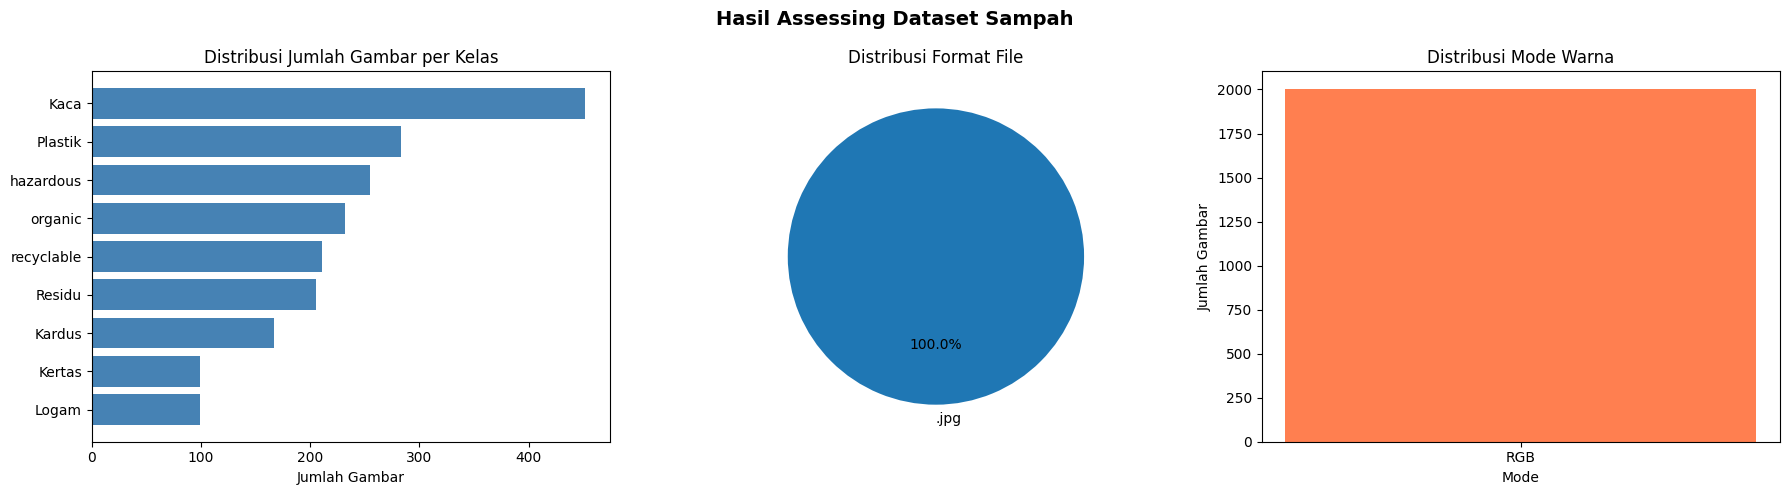

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Hasil Assessing Dataset Sampah", fontsize=14, fontweight="bold")

# distribusi kelas
class_counts = df["class"].value_counts()
axes[0].barh(class_counts.index, class_counts.values, color="steelblue")
axes[0].set_title("Distribusi Jumlah Gambar per Kelas")
axes[0].set_xlabel("Jumlah Gambar")
axes[0].invert_yaxis()

# distribusi format file
ext_counts = df["extension"].value_counts()
axes[1].pie(ext_counts.values, labels=ext_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Distribusi Format File")

# distribusi mode warna
mode_counts = df["mode"].value_counts()
axes[2].bar(mode_counts.index, mode_counts.values, color="coral")
axes[2].set_title("Distribusi Mode Warna")
axes[2].set_xlabel("Mode")
axes[2].set_ylabel("Jumlah Gambar")

plt.tight_layout()
plt.savefig("assessing_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

## DATA CLEANING

In [17]:
df.head()

,class,filename,path,extension,width,height,mode,file_size_kb
0,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,13.84
1,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,13.83
2,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,12.78
3,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,14.76
4,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,15.88


### CLEANING — Menghapus Gambar Rusak

In [18]:
def remove_broken_images(broken_images):
    """Menghapus gambar yang tidak dapat dibuka (rusak)."""
    removed = 0
    for img_path in broken_images:
        path = Path(img_path)
        if path.exists():
            path.unlink()
            removed += 1
            print(f"[HAPUS] {img_path}")

    print(f"\nTotal gambar rusak dihapus: {removed}")


remove_broken_images(broken_images)


Total gambar rusak dihapus: 0


### CLEANING — Identifikasi Duplikat Nama File

In [19]:
# mengidentifikasi duplikat berdasarkan nama file
duplicates = df[df["filename"].duplicated(keep=False)].copy()

if duplicates.empty:
    print("Tidak ditemukan duplikat nama file.")
else:
    print(f"Ditemukan {len(duplicates)} baris dengan nama file duplikat:")
    print(duplicates[["class", "filename", "path"]].to_string(index=False))
    duplicates.to_csv("duplicates_report.csv", index=False)
    print("\nLaporan duplikat disimpan ke duplicates_report.csv")

Tidak ditemukan duplikat nama file.


### CLEANING — Identifikasi Mode Warna Non-RGB

In [20]:
# mengidentifikasi gambar dengan mode warna bukan RGB
non_rgb = df[df["mode"] != "RGB"].copy()

if non_rgb.empty:
    print("Semua gambar sudah dalam mode RGB.")
else:
    print("Distribusi mode warna non-RGB:")
    print(non_rgb["mode"].value_counts())
    print(f"\nTotal gambar non-RGB: {len(non_rgb)}")
    non_rgb[["class", "filename", "mode"]].head(10)

Semua gambar sudah dalam mode RGB.


- gambar dengan mode selain RGB (seperti `RGBA`, `L`, `P`) perlu dikonversi ke `RGB` sebelum digunakan sebagai input model klasifikasi

### CLEANING — Menghapus Gambar Terlalu Kecil (< 32x32 px)

In [21]:
MIN_WIDTH = 32
MIN_HEIGHT = 32


def remove_tiny_images(df, min_width=MIN_WIDTH, min_height=MIN_HEIGHT):
    """Menghapus gambar yang resolusinya di bawah ambang batas minimum."""
    tiny = df[(df["width"] < min_width) | (df["height"] < min_height)].copy()

    if tiny.empty:
        print(f"Tidak ada gambar dengan resolusi di bawah {min_width}x{min_height} px.")
    else:
        print(f"Ditemukan {len(tiny)} gambar dengan resolusi terlalu kecil:")
        removed = 0
        for _, row in tiny.iterrows():
            path = Path(row["path"])
            if path.exists():
                path.unlink()
                removed += 1
                print(f"[HAPUS] {row['path']} ({row['width']}x{row['height']} px)")

        print(f"\nTotal gambar kecil dihapus: {removed}")

    return tiny


tiny_df = remove_tiny_images(df)

Tidak ada gambar dengan resolusi di bawah 32x32 px.


### CLEANING — Reassess Setelah Cleaning

In [22]:
# melakukan assess ulang setelah proses cleaning selesai
df_clean, broken_after = assess_dataset()

print("Jumlah gambar per kelas setelah cleaning:")
print(df_clean["class"].value_counts())

Jumlah gambar per kelas setelah cleaning:
class
Kaca          452
Plastik       283
hazardous     255
organic       232
recyclable    211
Residu        205
Kardus        167
Kertas         99
Logam          99
Name: count, dtype: int64


In [23]:
# mengecek kembali kondisi dataset setelah proses cleaning
print(f"Total gambar tersisa  : {len(df_clean)}")
print(f"Gambar rusak tersisa  : {len(broken_after)}")
print(f"Mode warna non-RGB    : {(df_clean['mode'] != 'RGB').sum()}")
print(f"Duplikat nama file    : {df_clean['filename'].duplicated().sum()}")

Total gambar tersisa  : 2003
Gambar rusak tersisa  : 0
Mode warna non-RGB    : 0
Duplikat nama file    : 0


In [24]:
# menyimpan laporan dataset bersih ke file CSV
df_clean.to_csv("clean_dataset_report.csv", index=False)
print("Laporan dataset bersih disimpan ke clean_dataset_report.csv")

Laporan dataset bersih disimpan ke clean_dataset_report.csv


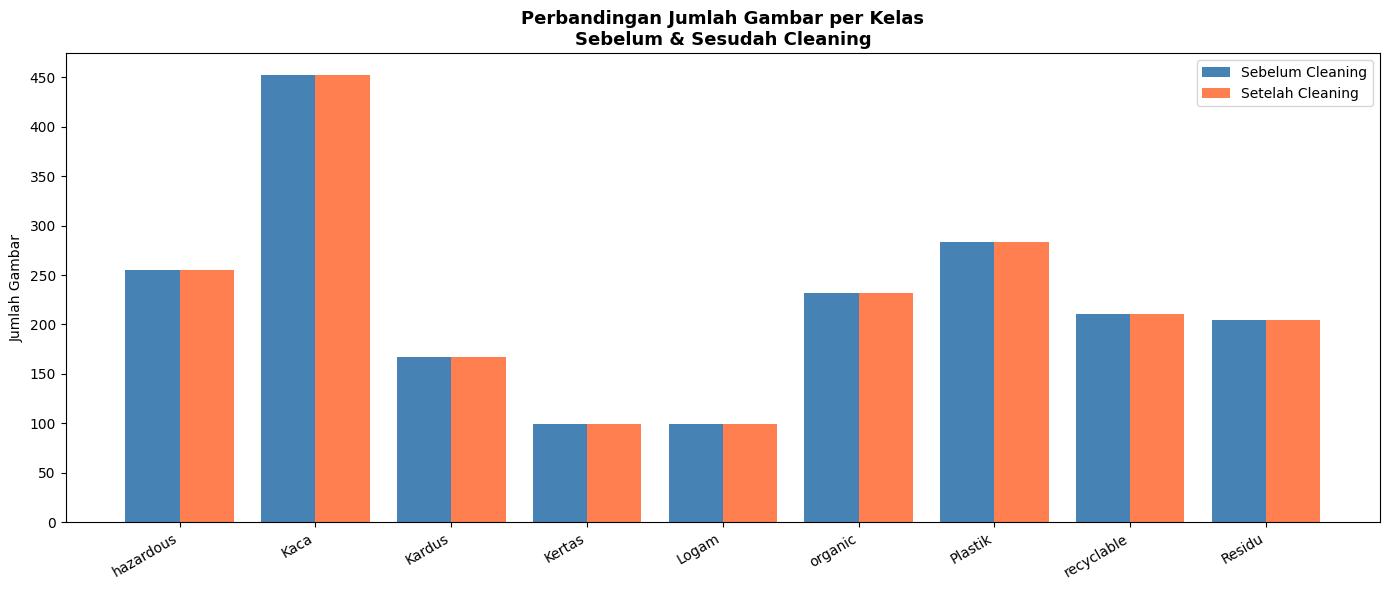

In [25]:
# visualisasi perbandingan jumlah gambar per kelas sebelum dan sesudah cleaning
before_counts = df["class"].value_counts().reindex(CLASSES, fill_value=0)
after_counts = df_clean["class"].value_counts().reindex(CLASSES, fill_value=0)

x = range(len(CLASSES))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width / 2 for i in x], before_counts.values, width, label="Sebelum Cleaning", color="steelblue")
ax.bar([i + width / 2 for i in x], after_counts.values, width, label="Setelah Cleaning", color="coral")

ax.set_title("Perbandingan Jumlah Gambar per Kelas\nSebelum & Sesudah Cleaning", fontsize=13, fontweight="bold")
ax.set_xticks(list(x))
ax.set_xticklabels(CLASSES, rotation=30, ha="right")
ax.set_ylabel("Jumlah Gambar")
ax.legend()
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("cleaning_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

setelah proses gathering, assessing, dan cleaning selesai:
- dataset terdiri dari 9 kelas sampah yang telah terstruktur di dalam folder `dataset/`
- gambar rusak, gambar terlalu kecil, dan duplikat telah dibersihkan
- laporan akhir tersimpan pada `clean_dataset_report.csv`
- dataset bersih siap digunakan untuk tahap augmentasi, feature extraction, atau pelatihan model klasifikasi gambar

In [26]:
df_clean

,class,filename,path,extension,width,height,mode,file_size_kb
0,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,13.84
1,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,13.83
2,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,12.78
3,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,14.76
4,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,dataset\hazardous\hazardous_hazardous_hazardou...,.jpg,224,224,RGB,15.88
...,...,...,...,...,...,...,...,...
1998,Residu,residu_residu_sampah-popok-bayi-sekali-pakai-c...,dataset\Residu\residu_residu_sampah-popok-bayi...,.jpg,224,224,RGB,25.32
1999,Residu,residu_residu_Sampah-Popok-yang-berhasil-dikum...,dataset\Residu\residu_residu_Sampah-Popok-yang...,.jpg,224,224,RGB,24.41
2000,Residu,residu_residu_tips-memilih-pembalut-yang-aman-...,dataset\Residu\residu_residu_tips-memilih-pemb...,.jpg,224,224,RGB,18.57
2001,Residu,residu_residu_tumpukan_popok_di_jembatan_dinoy...,dataset\Residu\residu_residu_tumpukan_popok_di...,.jpg,224,224,RGB,39.43
